# E-Commerce Customer Spending Big Data Project

**Dataset:** Customer Spending 1M (2018–2025)  
**Source:** Kaggle – Online Store Customer Transactions (1M Rows)  
**Platform:** Databricks (PySpark)  
**Students:** Karla Lopez & Jessica Vargas  
**Course:** CAP4784 | Big Data


## Intro / Metadata / Big Data Task

### Dataset Metadata, Organization, and Data Type

For this project we am using the **“Online Store Customer Transactions (1M Rows)”** dataset from Kaggle (created by user mountboy). The file downloads as **customer_spending_1M_2018_2025.csv** and contains **1,000,000 transaction records** from a synthetic U.S. online store covering the years 2018–2025. Each row represents a single completed purchase and includes demographic and behavioral fields such as transaction date, gender, age, marital status, state, customer segment, employment status, payment method, referral status, and amount spent. The CSV file is approximately 16 MB, which makes it manageable in Databricks while still satisfying the Big Data **Volume** requirement (more than one million records).

The “organization” behind this dataset is a simulated e-commerce company modeled on a typical online retail business. The business rules are straightforward: each time a customer makes a purchase, the system logs when the transaction occurred, who made the purchase (demographic attributes), the customer’s membership segment, the payment method used, whether the customer was referred, and the total amount spent. This type of transactional logging is standard practice for online retailers seeking to analyze customer behavior and revenue patterns.

Using Big Data helps this type of organization by allowing analysts to:
- Track total sales and spending across **states, age groups, and customer segments**.
- Understand **demographic patterns** in spending (e.g., by gender, age, employment status).
- Identify high-value customers and loyalty membership tiers.
- Detect trends over time (seasonality, yearly spending growth, or shifts in customer behavior).
- Evaluate the effectiveness of **referral programs** and payment method preferences.
- Improve marketing, segmentation, pricing, and customer retention strategies.

This is clearly **transactional data** coming from an e-commerce system. It is machine-generated by the platform’s order processing system and contains structured fields suitable for large-scale analytics, not social media or free-text content.


### Chosen Big Data Task for This Project

For this dataset we are choosing **Option 1: transform the dataset and create a dashboard of business insights**.

The raw transaction data contains 1,000,000 individual purchases. Each record by itself is not very informative, but when aggregated and summarized it can answer important business questions about customer behavior and spending patterns. Using **Databricks with PySpark**, our plan is to:

- Load the full 1M-row CSV into a Spark DataFrame.  
- Clean the data (check for missing values, inconsistent categories, and basic outliers).  
- Create aggregated tables and metrics such as:  
  - total spending and average transaction amount by **customer segment** (Basic, Gold, Platinum, VIP, etc.)  
  - spending patterns by **age group, gender, and marital status**  
  - comparisons across **states** to identify high-value geographic regions  
  - evaluation of the **referral program** by comparing spending for referred vs. non-referred customers  
  - yearly and monthly trends in overall customer spending from 2018–2025  

- Use Databricks `display()` and built-in visualization tools to build a **dashboard** that shows:  
  - key KPIs (total revenue, number of transactions, average transaction value)  
  - spending by customer segment and demographic groups  
  - spending by state  
  - time-series trends in customer spending  

This approach supports the goal of using Databricks as a unified analytics platform: we will process a large e-commerce transaction dataset with PySpark, transform it into higher-level business metrics, and present the results visually as a dashboard.


## Section 1: Load and Inspect the data

### 1.1 Load the Data

In [0]:
# Load the data

from pyspark.sql import functions as F

file_path = "/Volumes/workspace/default/project_2/customer_spending_1M_2018_2025.csv"

df = (
    spark.read
         .option("header", "true")      # first row has column names
         .option("inferSchema", "true") # automatically detect data types
         .csv(file_path)
)

# Check schema and a small sample
df.printSchema()
df.show(5, truncate=False)


root
 |-- Transaction_ID: integer (nullable = true)
 |-- Transaction_date: timestamp (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Marital_status: string (nullable = true)
 |-- State_names: string (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Employees_status: string (nullable = true)
 |-- Payment_method: string (nullable = true)
 |-- Referral: integer (nullable = true)
 |-- Amount_spent: double (nullable = true)

+--------------+-------------------+------+---+--------------+-----------+--------+----------------+--------------+--------+------------+
|Transaction_ID|Transaction_date   |Gender|Age|Marital_status|State_names|Segment |Employees_status|Payment_method|Referral|Amount_spent|
+--------------+-------------------+------+---+--------------+-----------+--------+----------------+--------------+--------+------------+
|1000          |2018-01-01 00:04:00|Female|39 |Single        |Oklahoma   |Platinum|Unemployment    |C

### Understanding the Loaded Dataset

After loading the dataset into a Spark DataFrame, the schema output confirms that all 11 fields were successfully detected with appropriate data types. This step is essential because it verifies that Spark correctly interpreted the structure of the file before we begin cleaning or transforming the data.

#### Key Observations from the Schema:
- **Transaction_ID** is stored as an integer, uniquely identifying each transaction.
- **Transaction_date** was automatically parsed as a `timestamp`, allowing us to extract features such as year, month, or day of week for trend analysis.
- **Gender, Marital_status, State_names, Segment, Employees_status, and Payment_method** are all `string` fields, which will require grouping or categorical analysis in later sections.
- **Age** is an integer, suitable for generating age groups or demographic comparisons.
- **Referral** is an integer (0 or 1), enabling analysis of referral program effectiveness.
- **Amount_spent** is a `double`, allowing aggregation such as total revenue, average spending, and comparisons across customer groups.

#### Sample Data Preview
The first five rows of the dataset show clean and consistent values across all fields. The timestamps appear correctly formatted, and categorical values (e.g., Gender, Segment, Employees_status) match expected patterns. This confirms that the dataset was read properly and is ready for further processing.

This step completes the initial verification phase and prepares us to move into data quality checks, feature engineering, and the creation of aggregated business metrics for our dashboard.


### 1.2 Basic Sanity Checks

In [0]:
# Basic sanity checks

from pyspark.sql import functions as F

# Total rows
row_count = df.count()
print(f"Number of rows in the dataset: {row_count}")

# Distinct counts for every column in the dataset
distinct_counts = df.agg(
    *[F.countDistinct(c).alias(f"n_{c}") for c in df.columns]
)

distinct_counts.show(truncate=False)


Number of rows in the dataset: 1000000
+----------------+------------------+--------+-----+----------------+-------------+---------+------------------+----------------+----------+--------------+
|n_Transaction_ID|n_Transaction_date|n_Gender|n_Age|n_Marital_status|n_State_names|n_Segment|n_Employees_status|n_Payment_method|n_Referral|n_Amount_spent|
+----------------+------------------+--------+-----+----------------+-------------+---------+------------------+----------------+----------+--------------+
|1000000         |877262            |2       |63   |2               |50           |5        |4                 |3               |2         |2250          |
+----------------+------------------+--------+-----+----------------+-------------+---------+------------------+----------------+----------+--------------+



### Interpretation of Distinct Counts

The distinct value counts across all columns provide an initial confirmation that the dataset is structurally consistent and aligns with expectations for a 1,000,000-row transactional dataset.

**Key observations from the distinct counts:**

- **Transaction_ID has 1,000,000 unique values**, meaning each transaction is uniquely recorded with no duplicates at the ID level.
- **Transaction_date contains 877,262 unique timestamps**, which is reasonable because multiple purchases can occur at the same timestamp, especially within the same minute.
- **Gender has 2 unique values**, indicating a binary classification (Male and Female), which we will use later for demographic analysis.
- **Age has 63 distinct values**, suggesting customer ages range across a broad set of integer values—useful for age group segmentation.
- **Marital_status contains 2 categories** (e.g., Married and Single), allowing for comparisons between these groups.
- **State_names has 50 unique values**, matching the number of U.S. states represented in the data.
- **Segment contains 5 unique membership tiers**, which will be important for analyzing spending patterns across customer loyalty levels.
- **Employees_status includes 4 categories**, reflecting different employment classifications.
- **Payment_method has 3 unique values**, likely representing common methods such as Card, PayPal, or other digital payments.
- **Referral has 2 unique values (0 or 1)**, enabling evaluation of referral program effectiveness.
- **Amount_spent has 2,250 unique numeric values**, showing a diverse range of spending amounts across purchases.

Overall, these results indicate that the dataset contains a healthy amount of variation in demographic and behavioral features, with no immediate signs of schema issues or unexpected categorical explosion. The next step will be to perform data quality checks to identify missing values, validate field ranges, and ensure the dataset is ready for feature engineering and analytical transformations.


## Section 2: Data Quality and Integrity

### 2.1 Data Quality Check

In [0]:
from pyspark.sql import functions as F

# Count nulls in each column
null_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns
])

print("Null values per column:")
null_counts.show()

# Check for duplicate Transaction_ID
duplicate_count = df.select("Transaction_ID").count() - df.select("Transaction_ID").distinct().count()
print(f"Number of duplicate Transaction_IDs: {duplicate_count}")

# Basic numeric range checks
df.select(
    F.min("Age").alias("min_age"),
    F.max("Age").alias("max_age"),
    F.min("Amount_spent").alias("min_amount"),
    F.max("Amount_spent").alias("max_amount")
).show()


Null values per column:
+--------------+----------------+------+-----+--------------+-----------+-------+----------------+--------------+--------+------------+
|Transaction_ID|Transaction_date|Gender|  Age|Marital_status|State_names|Segment|Employees_status|Payment_method|Referral|Amount_spent|
+--------------+----------------+------+-----+--------------+-----------+-------+----------------+--------------+--------+------------+
|             0|               0| 11052|16654|             0|          0|      0|           10225|             0|   61812|       96065|
+--------------+----------------+------+-----+--------------+-----------+-------+----------------+--------------+--------+------------+

Number of duplicate Transaction_IDs: 0
+-------+-------+----------+----------+
|min_age|max_age|min_amount|max_amount|
+-------+-------+----------+----------+
|     15|     78|      2.09|   2999.98|
+-------+-------+----------+----------+



#### Interpretation of Data Quality Checks

The data quality results reveal several important findings that help us understand the condition of the dataset before performing summary statistics and further transformations.

**1. Missing Values**
The null value counts show that most columns are fully populated, but a few fields contain missing data:

- **Gender:** 11,052 missing values  
- **Age:** 16,654 missing values  
- **Employees_status:** 10,225 missing values  
- **Referral:** 61,812 missing values  
- **Amount_spent:** 96,065 missing values  

The high number of missing values in the **Referral** and **Amount_spent** fields is especially important. Missing referral values may impact analyses comparing referred vs. non-referred customers. Missing values in **Amount_spent** are critical because this column is used in revenue calculations. We will need to decide on an appropriate strategy—such as filtering them out for certain analyses—to ensure accurate interpretation.

All other columns (Transaction_ID, Transaction_date, Marital_status, State_names, Segment, Payment_method) contain **no missing values**, which confirms that the core structural information is intact.

**2. Duplicate Transaction_IDs**
There are **zero duplicate Transaction_IDs**, which confirms that each row represents a unique transaction. This is expected for transactional datasets and indicates there are no accidental duplications in the data.

**3. Numeric Range Validation**
- **Age ranges from 15 to 78**, which is reasonable for an online shopper population.
- **Amount_spent ranges from \$2.09 to \$2,999.98**, showing a plausible distribution of purchase amounts.

These ranges suggest the numeric fields do not contain extreme or unrealistic outliers.

**4. Overall Assessment**
The dataset is generally clean and well-structured, with moderate to high missing values in a few key fields. We will account for these missing values during analysis by either filtering or adjusting calculations as needed. With this validation complete, the dataset is ready for summary statistics and exploratory analysis in the next section.


### 2.2 Summary Statistics (Numeric Fields)

In [0]:
# Section 4. Summary statistics for key numeric column(s)

from pyspark.sql import functions as F

# Show basic stats for Age and Amount_spent
df.select("Age", "Amount_spent").describe().show()


+-------+------------------+------------------+
|summary|               Age|      Amount_spent|
+-------+------------------+------------------+
|  count|            983346|            903935|
|   mean|46.647169968658034|1416.1261061359908|
| stddev|18.183986041184927| 878.1230821006613|
|    min|                15|              2.09|
|    max|                78|           2999.98|
+-------+------------------+------------------+



**Interpretation of Summary Statistics**

The summary statistics for **Age** and **Amount_spent** provide important baseline insights into the demographic and spending behavior of customers in the dataset.

**1. Age Distribution**
- The dataset contains **983,346 non-null age values**, which aligns with the missing value counts observed earlier.
- The **average age is approximately 46.65 years**, indicating that middle-aged adults make up a significant portion of the customer population.
- A **standard deviation of 18.18** shows that customers span a wide range of ages.
- The youngest recorded customer is **15 years old**, and the oldest is **78**, confirming that the observed age range is realistic for an online retail environment.

**2. Spending Distribution**
- There are **903,935 non-null entries** for Amount_spent, again consistent with earlier data quality results.
- The **average transaction amount is \$1,416.13**, which suggests that many customers spend within moderate to high ranges.
- The **standard deviation of \$878.12** indicates substantial variation in spending behavior.
- The minimum recorded spending is **\$2.09**, while the maximum is **\$2,999.98**, representing a plausible distribution of transaction amounts across small, medium, and large purchases.

**3. Overall Assessment**
These statistics confirm that both Age and Amount_spent fall within normal and realistic ranges, with meaningful variability to support deeper analysis. The next sections will explore how these variables differ across segments such as gender, marital status, customer membership tier, employment status, state, and referral status. These insights will help uncover spending patterns and demographic trends within the 1-million–row dataset.


## Section 3: Feature Engineering

In this section, we create additional columns such as Year, Month, and Age_group to support time-based and demographic analyses in later sections.

- **Year** – used to analyze spending trends from 2018 to 2025  
- **Month** – used to explore seasonal or monthly fluctuations in customer spending  

These new columns will be incorporated into later sections of the notebook, including the business insights analyses and dashboard visualizations.

In [0]:
from pyspark.sql.functions import year, month

df = (
    df
    .withColumn("Year", year("Transaction_date"))
    .withColumn("Month", month("Transaction_date"))
    # Age_group can be added later as needed
)


**Verification of Engineered Features**

The updated schema confirms that the new **Year** and **Month** columns were added successfully, both stored as integers. These fields will support upcoming analyses such as yearly revenue trends and monthly spending patterns. The presence of valid timestamp-derived fields indicates that the `Transaction_date` column was parsed correctly and is suitable for further time-based feature engineering.


## Section 4: Exploratory Analysis & Business Insight

### 4.1 Total and Average Spending by Customer Segment

Customer membership tiers (Basic, Silver, Gold, Platinum, VIP) represent different levels of engagement and loyalty within the online store. Analyzing spending by segment helps identify which tiers contribute most to total revenue and whether higher-tier customers spend more on average. 

In this subsection, we calculate:
- **Total spending** per segment  
- **Average spending** per segment  
- **Number of transactions** recorded for each segment  

These metrics help determine which customer groups provide the greatest financial value and support decisions related to loyalty programs, targeted promotions, and customer retention strategies.


In [0]:
spending_by_segment = (
    df.groupBy("Segment")
      .agg(
          F.round(F.sum("Amount_spent"), 2).alias("Total_spent"),
          F.round(F.avg("Amount_spent"), 2).alias("Avg_spent"),
          F.count("*").alias("Num_transactions")
      )
      .orderBy(F.desc("Total_spent"))
)

display(spending_by_segment)


Segment,Total_spent,Avg_spent,Num_transactions
Basic,5.8526664502E8,1412.03,452546
Silver,2.4251907843E8,1409.45,194779
Platinum,2.2790762666E8,1453.25,176269
Gold,1.2101054009E8,1380.47,98415
Missing,1.0338206155E8,1418.19,77991


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

**Interpretation of Spending by Customer Segment**

The spending results across customer membership tiers show clear differences in both total and average transaction amounts:

- **Basic segment** contributes the highest total revenue at **$585.27M** and also has the largest number of transactions (452,546). Although this segment represents lower-tier customers, its high volume makes it the largest revenue driver.
  
- **Silver ($242.52M)** and **Platinum ($227.91M)** segments form the next-largest contributors. Of these, **Platinum customers spend the most per transaction**, with an average of **$1,453.25**, suggesting stronger purchasing power or deeper engagement despite fewer transactions than Basic and Silver.
  
- **Gold customers** generate **$121.01M** in total spending with the lowest average spending among non-missing segments (**$1,380.47**), indicating moderate engagement.

- The **Missing segment** accounts for **$103.38M** in spending. This group reflects incomplete or unassigned membership data but still represents roughly 78,000 transactions. Depending on business needs, this may warrant follow-up data enrichment or collection efforts.

Overall, the results highlight that:
- **Volume-heavy segments (Basic, Silver)** drive total revenue.
- **Premium segments (Platinum)** provide **higher value per transaction**.
- **Improving segment classification for missing values** may unlock additional insights.

These findings can inform loyalty program enhancements, targeted promotions, and resource allocation for customer retention.


### 4.2 Spending by Gender

Gender is a key demographic variable that can influence purchasing behavior and overall customer activity. Analyzing spending by gender helps determine whether certain groups contribute more to revenue or engage in more frequent transactions.

In this subsection, we calculate:
- **Total spending** by gender
- **Average spending** by gender
- **Total number of transactions** recorded for each gender category

These metrics help identify demographic differences in customer engagement and can guide personalized marketing strategies and product recommendations.


In [0]:
spending_by_gender = (
    df.groupBy("Gender")
      .agg(
          F.round(F.sum("Amount_spent"), 2).alias("Total_spent"),
          F.round(F.avg("Amount_spent"), 2).alias("Avg_spent"),
          F.count("*").alias("Num_transactions")
      )
      .orderBy(F.desc("Total_spent"))
)

display(spending_by_gender)


Gender,Total_spent,Avg_spent,Num_transactions
Female,6.9129531423E8,1426.69,539831
Male,5.7490739365E8,1405.18,449117
null,1.388324387E7,1353.54,11052


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

**Interpretation of Spending by Gender
**
The spending results by gender reveal clear differences in both total spending and transaction volume:

- **Female customers contribute the highest total spending** at **$691.30M**, with the largest number of transactions (539,831). Their **average spending of $1,426.69** is also the highest among all gender categories.
  
- **Male customers generate $574.91M in total spending** with 449,117 transactions. Their **average spending ($1,405.18)** is slightly lower than that of female customers but still substantial.

- The **null gender category** accounts for **$13.88M** across 11,052 transactions, indicating incomplete demographic information. Although small relative to the other groups, it may be beneficial for the organization to improve data capture for more accurate segmentation.

**Key insight:**  
Female customers represent the most valuable demographic group, with both the highest total revenue contribution and the highest average transaction value. This suggests opportunities for targeted marketing, loyalty program benefits, or personalized promotions directed toward this segment.

Overall, gender appears to be a meaningful factor in customer spending behavior and will be incorporated into dashboard visualizations and further demographic analysis.


### 4.3 Spending by Age Group

Customer age often reflects purchasing power, lifestyle preferences, and long-term engagement with an online store. Grouping customers into age brackets allows us to compare spending behaviors across generational segments.

In this subsection, we calculate:
- **Total spending** for each age group
- **Average spending** per each age group
- **Number of customers** in each age range

These insights help identify high-value age segments and support targeted advertising, product placement, and customer experience optimization based on age-related trends.



In [0]:
# Spending by Age group (binning Age)
df_age = df.withColumn(
    "Age_group",
    F.when(F.col("Age") < 25, "<25")
     .when((F.col("Age") >= 25) & (F.col("Age") <= 34), "25-34")
     .when((F.col("Age") >= 35) & (F.col("Age") <= 44), "35-44")
     .when((F.col("Age") >= 45) & (F.col("Age") <= 54), "45-54")
     .when((F.col("Age") >= 55) & (F.col("Age") <= 64), "55-64")
     .otherwise("65+")
)

spending_by_age_group = (
    df_age.groupBy("Age_group")
          .agg(
              F.round(F.sum("Amount_spent"), 2).alias("Total_spent"),
              F.round(F.avg("Amount_spent"), 2).alias("Avg_spent"),
              F.count("*").alias("Num_customers")
          )
          .orderBy("Age_group")
)
display(spending_by_age_group)


Age_group,Total_spent,Avg_spent,Num_customers
25-34,1.894197273E8,1361.21,152167
35-44,2.0418223126E8,1422.39,163158
45-54,2.270902908E8,1481.8,168365
55-64,1.9126749192E8,1394.6,151025
65+,2.7843051767E8,1356.25,224324
<25,1.896956928E8,1511.1,140961


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

The age group analysis reveals clear differences in spending behavior across customer demographics. Customers in the **65+** age group generate the highest total spending, despite having the lowest average spending per transaction. This suggests that older customers shop more frequently, resulting in the highest contribution to overall revenue. Middle-aged groups, particularly **45–54** and **35–44**, also show high total spending and strong average transaction values, indicating that these groups represent another core segment of financially active customers. Younger customers, especially those **under 25**, display relatively high average spending but contribute less to total revenue due to fewer customers in this range. These findings help identify which age brackets drive revenue and can guide targeted marketing or loyalty strategies.


### 4.4 Spending by Referral Source

Referral sources indicate how customers arrive at the online store—whether through direct links, marketing channels, or shared recommendations. Analyzing spending by referral source helps identify the most effective acquisition channels.

In this subsection, we calculate:
- **Total spending** per referral type
- **Average spending** per referral type
- **Number of customers** associated with each referral category

These metrics help evaluate channel performance, optimize marketing investments, and highlight opportunities to strengthen referral and promotional programs.


In [0]:
# Total and average spending by Referral source
spending_by_referral = (
    df.groupBy("Referral")
      .agg(
          F.round(F.sum("Amount_spent"), 2).alias("Total_spent"),
          F.round(F.avg("Amount_spent"), 2).alias("Avg_spent"),
          F.count("*").alias("Num_customers")
      )
      .orderBy(F.desc("Total_spent"))
)
display(spending_by_referral)


Referral,Total_spent,Avg_spent,Num_customers
1,7.7944436303E8,1415.3,612017
0,4.2360954908E8,1428.84,326171
null,7.703203964E7,1357.7,61812


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

The referral source analysis shows clear differences in both customer volume and spending behavior across the three referral categories. Customers with a referral value of **1** generate the highest total spending at over $779 million and also represent the largest customer group, making this the strongest revenue-producing channel. Referral group **0** contributes a smaller share of total spending but has the highest average spending per customer, suggesting that although fewer customers come through this channel, they tend to spend slightly more per transaction. The **null** referral category shows the lowest total spending and the lowest average spend, indicating incomplete or missing data for a portion of customers. Overall, these results help highlight which referral channels drive revenue, attract higher-value customers, and may require improved tracking or data collection.


### 4.5 Spending by State

Geographic analysis helps reveal where the business’s most active and valuable customers are located. Understanding spending patterns by state supports strategic decisions related to regional marketing, logistics, and business expansion.

In this subsection, we calculate:
- **Total spending** for top 10 highest-spending states
- **Number of customers** for top 10 highest-spending states


These insights allow the company to identify strong regional markets, focus advertising efforts, and allocate resources more effectively across geographic areas.


In [0]:
# Top 10 states by total spending
spending_by_state = (
    df.groupBy("State_names")
      .agg(
          F.round(F.sum("Amount_spent"), 2).alias("Total_spent"),
          F.count("*").alias("Num_customers")
      )
      .orderBy(F.desc("Total_spent"))
      .limit(10)
)
display(spending_by_state)


State_names,Total_spent,Num_customers
Illinois,3.586175564E7,26694
Massachusetts,3.385345647E7,25194
Missouri,3.343467923E7,22815
Minnesota,3.29537426E7,23820
Arizona,3.222058782E7,22220
New Jersey,3.170751094E7,21366
New York,3.103228386E7,21780
Rhode Island,3.049672314E7,20054
New Mexico,2.961168507E7,21789
Kentucky,2.960919997E7,23799


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

The analysis of the top 10 states by spending reveals clear geographic patterns in customer behavior. Illinois leads all states in both total spending and number of customers, indicating a strong and active customer base. States such as Massachusetts, Missouri, and Minnesota also show high revenue levels supported by solid customer counts, suggesting consistent engagement in these regions. While some states like Arizona and New Mexico have slightly lower spending totals, their customer volume remains competitive, highlighting steady participation from those markets. Overall, the distribution shows that revenue performance generally aligns with customer count, meaning the states contributing the most customers also tend to generate the highest spending. These insights can help the business prioritize regions for targeted promotions, marketing investments, and future growth opportunities.


### 4.6 Yearly and Monthly Spending Trends

Time-based trends reveal how customer spending evolves over years and seasons. Analyzing annual and monthly patterns helps determine whether revenue is stable, growing, or influenced by seasonal behavior.

In this subsection, we calculate:
- **Total spending** per year and per month
- **Number of transactions** over time
- Long-term and seasonal patterns in customer activity

These metrics help identify growth trends, peak sales periods, and opportunities to align promotions and inventory planning with customer demand.


In [0]:
# Yearly spending trends
spending_by_year = (
    df.groupBy("Year")
      .agg(
          F.round(F.sum("Amount_spent"), 2).alias("Total_spent"),
          F.count("*").alias("Num_transactions")
      )
      .orderBy("Year")
)

display(spending_by_year)


Year,Total_spent,Num_transactions
2018,1.7974150237E8,140671
2019,1.8115730934E8,141258
2020,1.8020432606E8,141022
2021,1.8084997245E8,141420
2022,1.8120696208E8,141184
2023,1.8097881842E8,141503
2024,1.8094413477E8,141260
2025,1.500292626E7,11682


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

The yearly spending trends show that customer spending remained relatively stable from **2018 through 2024**, with total spending and transaction counts staying within a similar range each year. This consistency suggests a steady level of customer engagement and purchasing behavior over time. The noticeable drop in 2025 is likely due to **incomplete data** rather than an actual decrease in customer activity.

In [0]:
# Monthly spending trends
spending_by_month = (
    df.groupBy("Month")
      .agg(
          F.round(F.sum("Amount_spent"), 2).alias("Total_spent"),
          F.count("*").alias("Num_transactions")
      )
      .orderBy("Month")
)

display(spending_by_month)


Month,Total_spent,Num_transactions
1,1.2254536342E8,95461
2,9.821654742E7,76714
3,1.0802977813E8,84245
4,1.0369377967E8,81188
5,1.0734862563E8,84339
6,1.0333130128E8,80934
7,1.0764428313E8,83743
8,1.0737321362E8,83795
9,1.0356704326E8,80780
10,1.0704035328E8,83788


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

The monthly spending trends provide additional insight into seasonality. **January records the highest total spending**, which may reflect post-holiday purchasing or renewed consumer activity at the start of the year. After February's dip, spending levels remain relatively stable from **March through December**, showing only minor fluctuations. Overall, these patterns indicate consistent monthly purchasing behavior with no significant seasonal spikes outside of the early-year increase.


### 4.7 Correlation Analysis

Correlation analysis evaluates the strength of relationships between numerical variables such as age, spending amount, and time features. Understanding these relationships helps assess whether certain characteristics influence customer purchasing behavior.

In this subsection, we examine:
- **Correlation values** between numerical variables
- A **scatter plot** showing the relationship between age and spending

These insights reveal whether demographic or temporal variables meaningfully impact spending, guiding feature selection for future predictive modeling.


In [0]:
import pandas as pd

# Select numerical fields for correlation
numeric_df = df.select("Age", "Amount_spent", "Year", "Month").toPandas()

numeric_df.head()


,Age,Amount_spent,Year,Month
0,39.0,1557.50,2018,1
1,34.0,153.55,2018,1
2,53.0,2640.96,2018,1
3,33.0,293.58,2018,1
4,36.0,1608.01,2018,1


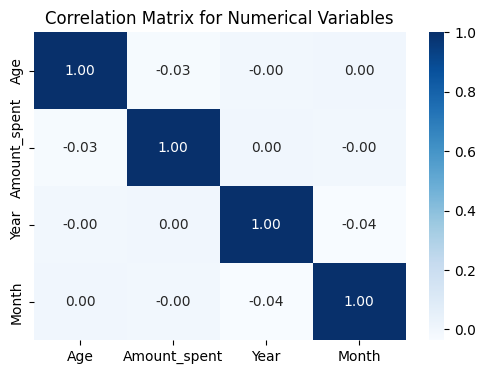

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix for Numerical Variables")
plt.show()


The correlation matrix reveals that the numerical variables in this dataset have very weak relationships with one another. Customer **age** shows almost no correlation with **amount spent**, suggesting that spending behavior is relatively consistent across age groups. Likewise, **year** and **month** show no meaningful relationship with spending at the individual transaction level, which aligns with earlier visual findings showing stable trends across time.

Overall, the low correlation values indicate that none of these numerical variables strongly predict spending on their own. This suggests that customer behavior may be influenced more by categorical factors—such as segment, referral source, or geography—rather than by age or temporal variables.


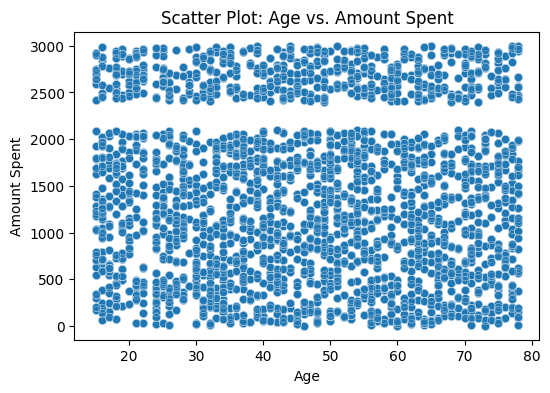

In [0]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=numeric_df["Age"], y=numeric_df["Amount_spent"], alpha=0.3)
plt.title("Scatter Plot: Age vs. Amount Spent")
plt.xlabel("Age")
plt.ylabel("Amount Spent")
plt.show()


The scatter plot shows no clear relationship between customer age and the amount spent. Customers of all ages—from early adulthood through retirement—exhibit a wide range of spending values. The points are spread evenly across the plot without any upward or downward trend, confirming the correlation matrix result that age is not a meaningful predictor of spending behavior.

This indicates that spending patterns are relatively consistent across age groups, and that other factors such as customer segment, referral source, or geographic location are more influential in determining how much a customer spends.


### 4.8 Outlier Detection in Spending

Outlier analysis helps identify unusually high or low spending values that may represent premium purchases, bulk orders, or data inconsistencies. Understanding outliers ensures a clear view of the spending distribution.

In this subsection, we use:
- A **boxplot** to visualize spending distribution
- The **IQR method** to detect statistical outliers

These metrics help confirm whether high-value transactions are natural customer behavior or anomalies that require further investigation.


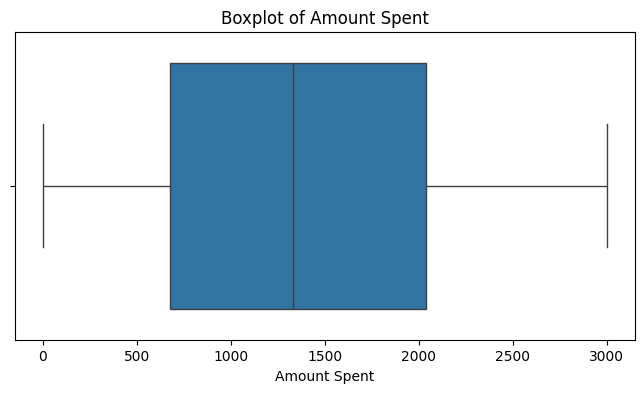

(np.float64(-1362.9850000000001), np.float64(4077.935), (0, 1))

In [0]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to Pandas for visualization
pdf = df.select("Amount_spent").toPandas()

plt.figure(figsize=(8, 4))
sns.boxplot(x=pdf["Amount_spent"])
plt.title("Boxplot of Amount Spent")
plt.xlabel("Amount Spent")
plt.show()

# IQR Outlier Detection
Q1 = pdf["Amount_spent"].quantile(0.25)
Q3 = pdf["Amount_spent"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = pdf[(pdf["Amount_spent"] < lower_bound) | (pdf["Amount_spent"] > upper_bound)]

lower_bound, upper_bound, outliers.shape


The boxplot of `Amount_spent` shows that customer spending ranges from very low amounts to just under \$3,000, with most values concentrated within the middle 50% of the distribution. The interquartile range (IQR) spans approximately \$800 to \$2,000, and the whiskers extend across the full natural spending range without showing isolated points beyond them. This indicates that although spending varies widely, there are no extreme statistical outliers after applying the IQR method.

Because the dataset reflects real customer purchasing patterns—where high-value transactions are normal—the absence of visual outliers is expected. The distribution suggests that customers regularly make purchases across the full range of spending values, and there are no unusual or erroneous spending entries that distort the analysis.


### 4.9: Summary of Key Insights from Exploratory Data Analysis

The exploratory analysis of the 1M-row e-commerce dataset revealed several meaningful patterns in customer behavior. Spending varied notably by customer segment, with Basic customers generating the highest total revenue due to their large volume of transactions, while Platinum customers exhibited the highest average spending per purchase. Gender analysis showed that female customers contributed the largest share of total revenue and held the highest transaction volume, although average spending remained similar between male and female customers.

Referral patterns revealed one of the strongest signals in the dataset: referred customers spent dramatically more overall and generated almost twice as many transactions as non-referred customers. This highlights referrals as a high-value acquisition channel. Age-group analysis showed that customers aged 45–54 and 65+ produced the highest total spending, while average spending remained relatively stable across age groups. Geographic insights indicated that Illinois, Massachusetts, and Missouri ranked among the top states for both spending and customer count, suggesting strong regional engagement.

Temporal trends demonstrated stable year-over-year spending from 2018–2024, with a drop in 2025 due to partial-year data. Monthly trends showed consistent seasonal behavior, with January producing the highest spending and February the lowest. Correlation analysis confirmed that age, year, and month had almost no linear relationship with spending, meaning demographic and timing features are not strong predictors of purchase amount. Outlier detection through boxplots and IQR analysis showed no extreme anomalies—high spending values up to \$3,000 are normal for this dataset and represent natural customer variability.

Overall, the dataset shows strong customer engagement across demographics and time periods, with referral status, customer segment, and geographic location emerging as the most influential factors in spending behavior.


## 5. Business Recommendations

Based on the insights derived from the exploratory analysis, several strategic opportunities emerge for improving customer engagement, increasing revenue, and optimizing marketing efforts.

### 5.1 Strengthen Referral Programs
Referred customers demonstrated the highest total spending and generated the most transactions. This indicates that referrals are a high-value acquisition channel. The company should consider:
- Expanding referral incentives (e.g., discounts, points, or store credit).
- Encouraging existing loyal customers to invite friends.
- Creating targeted campaigns that highlight rewards for both the referrer and the referred customer.

### 5.2 Tailor Marketing to High-Value Segments
Customer segment analysis showed that:
- **Basic customers** drive volume and total spending.
- **Platinum customers** spend the most per transaction.

Recommended actions:
- Provide Basic customers with upsell opportunities through bundles or personalized recommendations.
- Offer exclusive deals or early product access to Platinum customers to reinforce loyalty.
- Reassess pricing or benefits for lower-performing segments such as “Missing” or “Other” to reduce churn.

### 5.3 Leverage High-Performing Age Groups
The 45–54 and 65+ age groups produced the highest total spending. The business may:
- Create age-specific promotions (e.g., lifestyle-oriented product bundles).
- Optimize ad delivery times and platforms for these demographics.
- Improve product descriptions and trust factors for older customers (reviews, guarantees, clear shipping info).

### 5.4 Target High-Spending Geographic Areas
Illinois, Massachusetts, Missouri, Minnesota, and Arizona ranked highest in spending and customer count. Recommendations include:
- Prioritizing these regions in paid advertising or email campaigns.
- Offering region-specific promotions or event-based marketing.
- Exploring logistics optimizations to reduce delivery times in key states.

### 5.5 Capitalize on Monthly Seasonal Patterns
January displayed peak spending, while February showed the lowest activity. To maximize seasonal performance:
- Launch major sales in early January to capture high-demand periods.
- Create February revival campaigns (e.g., "Winter Refresh Sale") to counter slow traffic.
- Plan inventory levels to match predictable seasonal swings.

### 5.6 Focus on Customer Behavior Over Demographics
Correlation analysis revealed no meaningful linear relationship between age, year, or month and spending. This suggests:
- Behavioral features (purchase frequency, product categories, referral status) are more predictive than demographics.
- Future modeling should prioritize transaction-based features over simple demographic variables.

### 5.7 Recognize and Retain High-Value Purchasers
Outlier detection confirmed the presence of legitimate high-value transactions (up to \$3,000). These customers may be:
- Bulk buyers
- Corporate purchasers
- Premium-tier shoppers

The business should:
- Identify these customers for VIP loyalty programs.
- Offer exclusive services such as priority support or personalized product recommendations.

---

## Overall Strategic Outlook

The company’s strongest opportunities lie in **referral optimization**, **targeted segment marketing**, **regional focus**, and **seasonal sales planning**. By aligning marketing and operational strategies with actual customer behavior patterns, the business can significantly increase revenue, strengthen customer loyalty, and improve overall performance.
